In [1]:
#NECESSARY LIBARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#READ THE DATA
df = pd.read_csv('Iris 2.5.csv')

In [3]:
#top 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
#statistical information
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.shape

(150, 6)

In [7]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [8]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [9]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
df.groupby(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm','Species']).size()

SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species       
4.3            3.0           1.1            0.1           Iris-setosa       1
4.4            2.9           1.4            0.2           Iris-setosa       1
               3.0           1.3            0.2           Iris-setosa       1
               3.2           1.3            0.2           Iris-setosa       1
4.5            2.3           1.3            0.3           Iris-setosa       1
                                                                           ..
7.7            2.6           6.9            2.3           Iris-virginica    1
               2.8           6.7            2.0           Iris-virginica    1
               3.0           6.1            2.3           Iris-virginica    1
               3.8           6.7            2.2           Iris-virginica    1
7.9            3.8           6.4            2.0           Iris-virginica    1
Length: 147, dtype: int64

In [11]:
df['Species'] = df['Species'].map({'Iris-setosa' : 0, 'Iris-versicolor' : 1, 'Iris-virginica' : 2})

In [12]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


### DATA VISUALIZATION

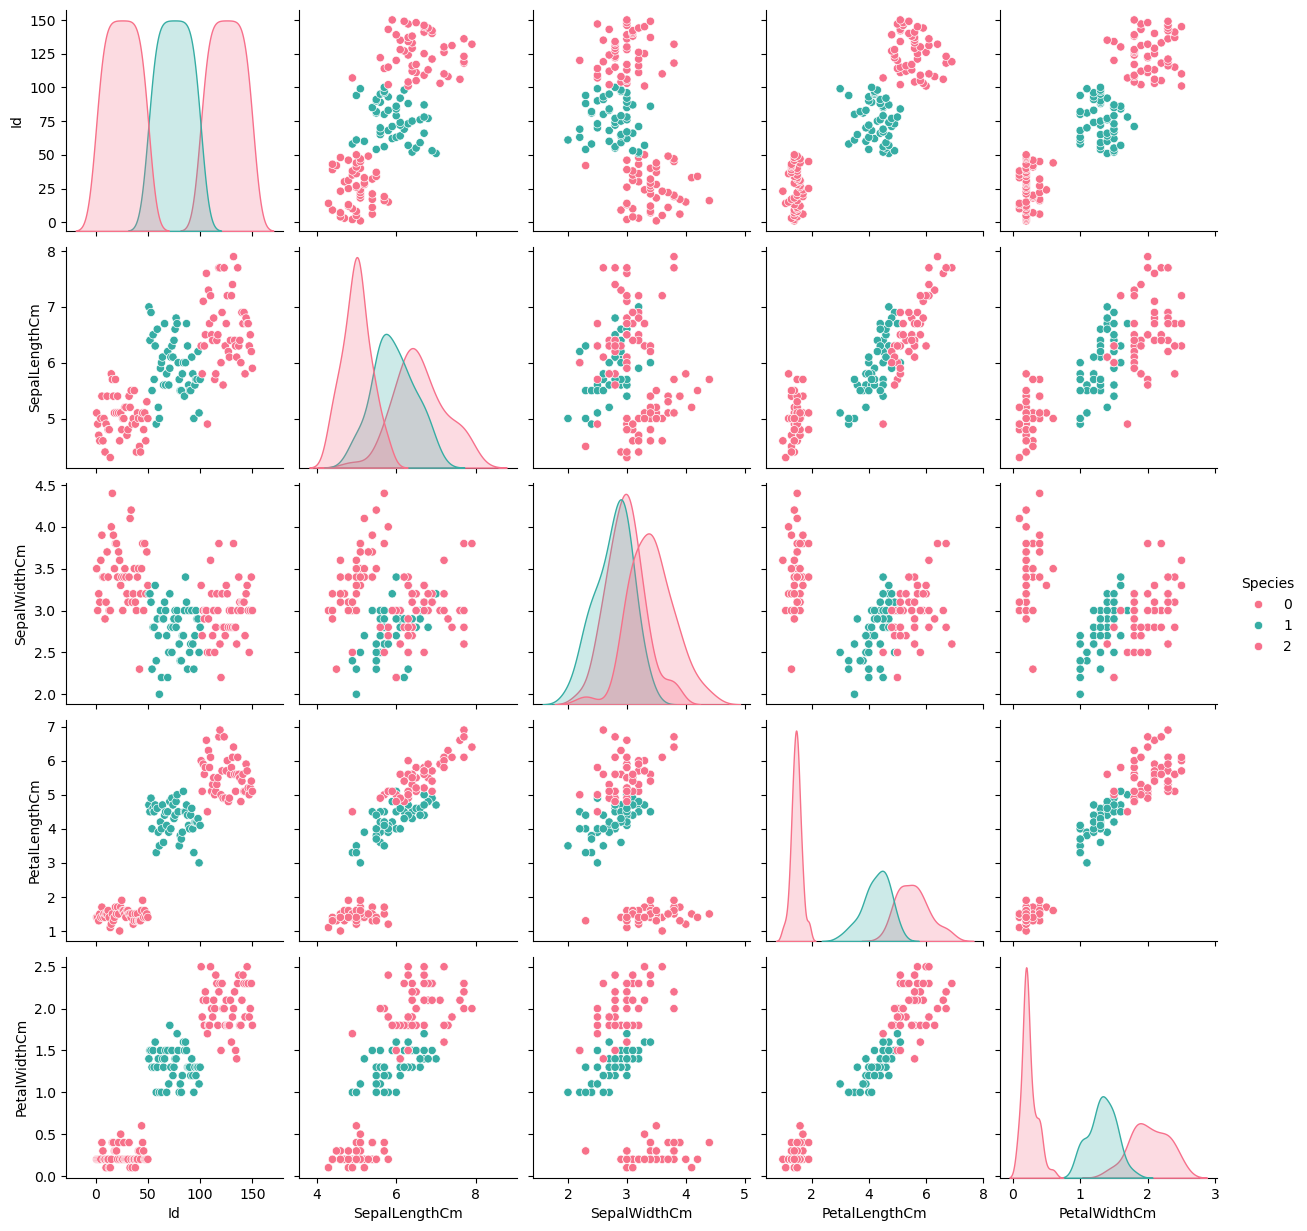

In [14]:
sns.pairplot(df, hue = 'Species', palette = 'husl')
plt.show()

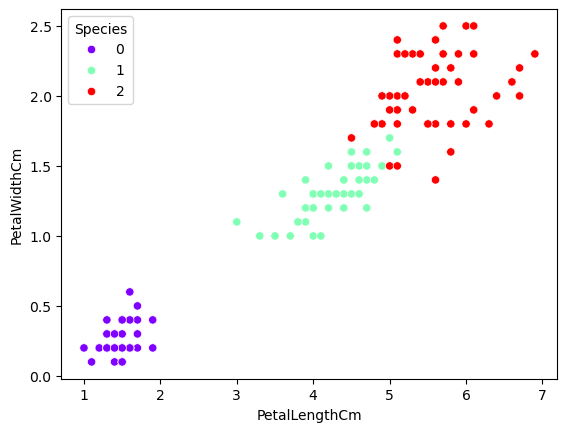

In [15]:
sns.scatterplot(x = 'PetalLengthCm', y = 'PetalWidthCm', data = df, hue = 'Species', palette = 'rainbow', alpha = 1)
plt.show()

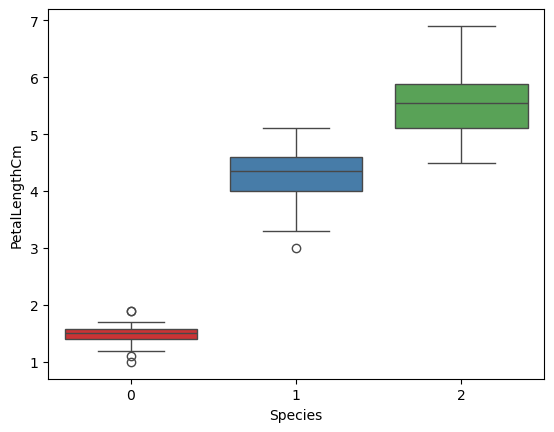

In [16]:
sns.boxplot(x = 'Species', y = 'PetalLengthCm', data = df, palette = 'Set1', hue = 'Species', legend = False)
plt.show()

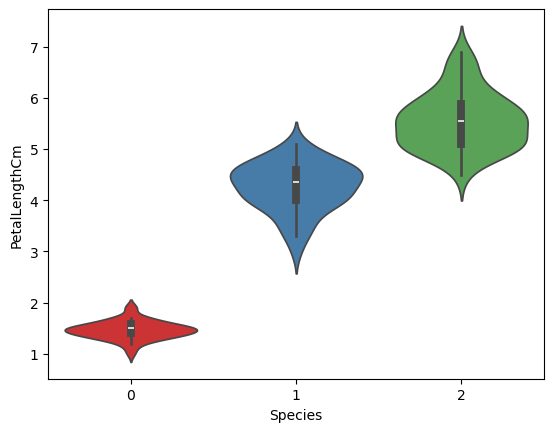

In [17]:
sns.violinplot(x = 'Species', y = 'PetalLengthCm', data = df, palette = 'Set1', hue = 'Species', legend = False)
plt.show()

<Axes: >

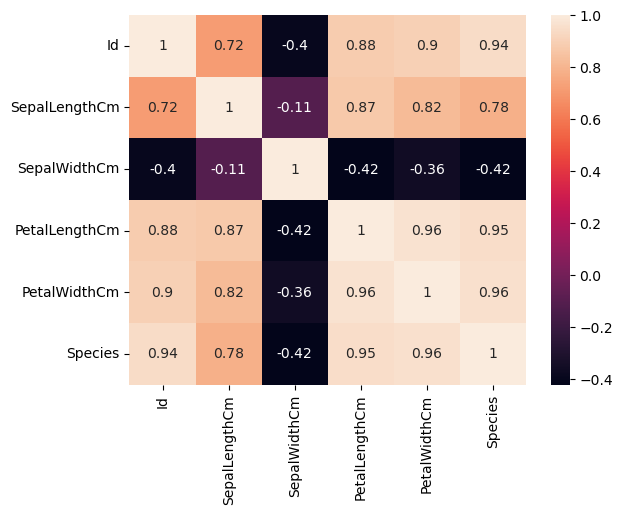

In [18]:
#CORRELATION
sns.heatmap(df.corr(),annot = True)

### Split the columns into input and target variable

In [20]:
x = df.drop(columns = ['Species'])
y = df['Species']

### Standardise the data with StandardScaler

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
xcolumns = x.columns

In [25]:
x = scaler.fit_transform(x)

In [26]:
x = pd.DataFrame(x,columns = xcolumns)

In [27]:
x.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-1.720542,-0.900681,1.032057,-1.341272,-1.312977
1,-1.697448,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.674353,-1.385353,0.337848,-1.398138,-1.312977
3,-1.651258,-1.506521,0.106445,-1.284407,-1.312977
4,-1.628164,-1.021849,1.263460,-1.341272,-1.312977


### Split the data into training and testing set

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state = 100)

In [31]:
x_train.shape

(105, 5)

In [32]:
x_test.shape

(45, 5)

### 1. K-Nearest Neighbors

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
knn_model = KNeighborsClassifier(n_neighbors=1)

In [36]:
knn_model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [37]:
knn_model.score(x_train,y_train)

1.0

In [38]:
y_pred_knn = knn_model.predict(x_test)

In [39]:
from sklearn import metrics

In [40]:
metrics.accuracy_score(y_test,y_pred_knn)

0.9777777777777777

In [41]:
metrics.confusion_matrix(y_test,y_pred_knn)

array([[16,  0,  0],
       [ 0, 11,  0],
       [ 0,  1, 17]], dtype=int64)

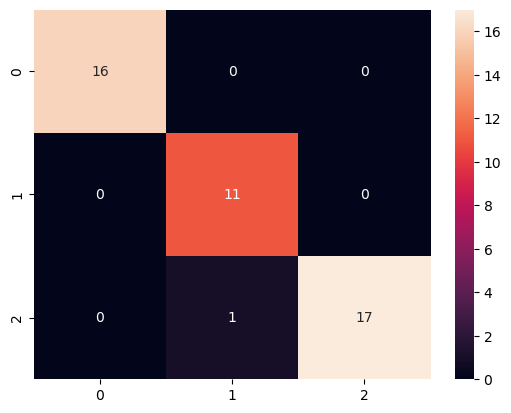

In [42]:
sns.heatmap(metrics.confusion_matrix(y_test,y_pred_knn), annot = True, fmt = 'd')
plt.show()

In [43]:
print(metrics.classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.92      1.00      0.96        11
           2       1.00      0.94      0.97        18

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [44]:
error_rate = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train,y_train)
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i != y_test))

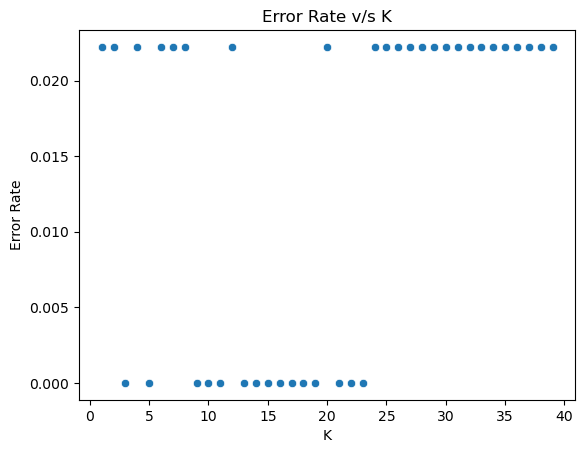

In [45]:
sns.scatterplot(x = range(1,40),y = error_rate)
plt.title('Error Rate v/s K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

WITH K=1


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.92      1.00      0.96        11
           2       1.00      0.94      0.97        18

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



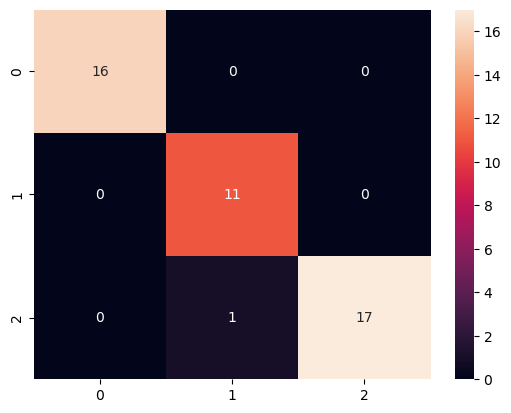

r2 score of our model is : 0.9696765498652291


In [46]:
knn = KNeighborsClassifier(n_neighbors = 1)

knn.fit(x_train,y_train)
pred = knn.predict(x_test)

print('WITH K=1')
print('\n')
print(metrics.classification_report(y_test,pred))
sns.heatmap(metrics.confusion_matrix(y_test,pred),annot = True, fmt = 'd')
plt.show()

print('r2 score of our model is :', metrics.r2_score(pred,y_test))

WITH K = 3


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        18

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



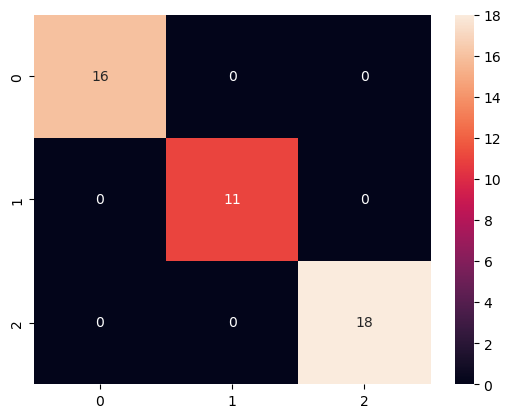

r2 score of the model is : 1.0


In [47]:
knn = KNeighborsClassifier(n_neighbors = 3)

knn.fit(x_train,y_train)
pred = knn.predict(x_test)

print('WITH K = 3')
print('\n')

print(metrics.classification_report(y_test,pred))
sns.heatmap(metrics.confusion_matrix(y_test,pred),annot = True, fmt = 'd')
plt.show()

print('r2 score of the model is :', metrics.r2_score(pred,y_test))

### 2. DECISION TREES

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
dt_model = DecisionTreeClassifier()

In [51]:
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [52]:
dt_model.score(x_train,y_train)

1.0

In [53]:
y_pred_dt = dt_model.predict(x_test)

In [54]:
metrics.accuracy_score(y_test,y_pred_dt)

0.9777777777777777

In [55]:
metrics.confusion_matrix(y_test,y_pred_dt)

array([[16,  0,  0],
       [ 0, 10,  1],
       [ 0,  0, 18]], dtype=int64)

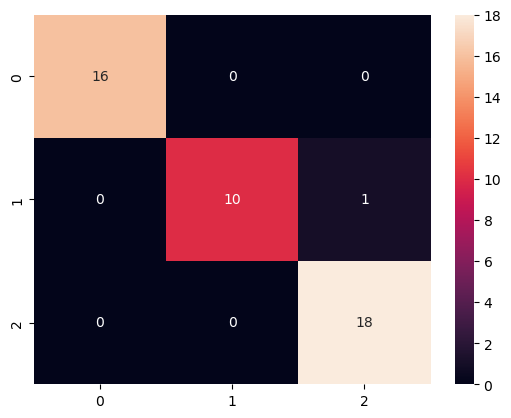

In [56]:
sns.heatmap(metrics.confusion_matrix(y_test,y_pred_dt), annot = True, fmt = 'd')
plt.show()

In [57]:
print(metrics.classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.91      0.95        11
           2       0.95      1.00      0.97        18

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45

